In [ ]:
from enhanceStain import AutoEnhancer
from TileSampling import WSITileSampler
import os,natsort
import openslide
import matplotlib.pyplot as plt
import numpy as np
import warnings
import cv2
import h5py
warnings.filterwarnings('ignore')

# dirs1 = '/home/nas2_fast/Data/Pathology_project/DIG_TNBC_proteomics_박종배박사님1차/wsi'
# files1 = natsort.natsorted(os.listdir(dirs1))

dirs2 = '/home/nas2_fast/Data/Pathology_project/TCGA-BRCA/wsi'
files2 = natsort.natsorted(os.listdir(dirs2))

files=[]
for i in range(len(files2)):    
    files.append(files2[i].replace('.svs',''))
# dirs3 = '/home/nas2_fast/Data/Pathology_project/PNU_samples/wsi'
# files3 = natsort.natsorted(os.listdir(dirs3))


In [ ]:
files2[0]

In [ ]:
import random
files=[]

# for i in range(15):
#     idxs=random.randrange(1, len(files1), 3)
#     files.append(files1[idxs].replace('.svs',''))
for i in range(len(files2)):
    # idxs=random.randrange(1, len(files2), 3)
    files.append(files2[i].replace('.svs',''))

# for i in range(len(files3)):
#     idxs=random.randrange(1, len(files3), 3)
#     files.append(files3[idxs].replace('.svs',''))



# files = ['TCGA-A2-A0ET-01Z-00-DX1.41E86BB9-EA52-4615-94E7-0F09DDB094F4',
#  'TCGA-E9-A244-01Z-00-DX1.4FDAA892-9DBF-4E5D-89F3-2A84C8AC8F0A',
#  'TCGA-E9-A1RE-01Z-00-DX1.fd100503-ba95-4af8-8e59-689b2cea145c',
#  'TCGA-OL-A66J-01Z-00-DX1.661F7F70-E4D4-4875-B8C4-556F7927F3BA',
#  'TCGA-E9-A54Y-01Z-00-DX1.5FD70369-6514-4E5E-8BEF-65DAC5671E1A',
#  'TCGA-D8-A1JT-01Z-00-DX1.F278C419-E405-4BDA-BA50-BFBA08801168',
#  'TCGA-E2-A15R-01Z-00-DX1.B58D2D9D-05EE-4D66-8DC0-9E5C6AD2E3D3',
#  'TCGA-LL-A5YM-01Z-00-DX1.2B8904A9-6A45-4FFD-AF15-EB81773E5B79',
#  'TCGA-BH-A28Q-01Z-00-DX1.C6D1CA93-6B2A-4722-9270-5D56592D833D',
#  'TCGA-A2-A0T0-01Z-00-DX1.51F904DA-A4B5-4451-8AEF-58E7EF7651DB',
#  'TCGA-BH-A0DO-01Z-00-DX1.1684557E-A5D4-4828-B2D5-FA899993A019',
#  'TCGA-A2-A0YG-01Z-00-DX1.89A39319-F880-47DE-B311-DA1F6A64B6F3',
#  'TCGA-A8-A08C-01Z-00-DX1.0602211C-1098-4711-AA41-8F56B11DB36F',
#  'TCGA-A2-A0T3-01Z-00-DX1.5E96BC87-F4FB-4ABA-8D81-FAB7F4A80661',
#  'TCGA-A8-A09Z-01Z-00-DX1.D56497BE-5099-4537-9600-60F3213F7BF5']
# files = ['TCGA-E9-A1RE-01Z-00-DX1.fd100503-ba95-4af8-8e59-689b2cea145c']
# files

In [ ]:
from stainNorm import TCGAStainNormalizer
from enhanceStain import get_imagej_enhanced_thumbnail
normalizer = TCGAStainNormalizer(output_path="inference_output")
normalizer.load_template("/home/nas2_fast/Codes/smlee/testCodes/normalization/output/templates/tcga_brca_template.json")


for file in files:
    svsPath = os.path.join(dirs2,f"{file}.svs")
    wsi = openslide.OpenSlide(svsPath)
    thumbnail = np.array(wsi.get_thumbnail(wsi.level_dimensions[-1]))

    image = get_imagej_enhanced_thumbnail(thumbnail)
    
    # results = normalizer.normalize_image(
    #     image=np.array(image),
    #     output_path=f"inference_results/{file}.png",
    #     return_image=True,
    #     save_comparison=True
    # )

    # # image = get_imagej_enhanced_thumbnail(results) 
    # plt.imshow(results)
    # plt.axis('off')
    # plt.show()
    break

In [ ]:
sampler = WSITileSampler(
        root_dir = dirs2,
        output_dir = os.path.join(os.getcwd(),'coords'),
        thumbnail_dir=os.path.join(os.getcwd(),'thumbnails_TCGA')
    )
results = sampler.process_images(files)

In [ ]:
coDir = f'{os.getcwd()}/coords'
# files = [i for i in natsort.natsorted(os.listdir(coDir)) if i.endswith('.h5')]
os.makedirs(os.path.join(os.getcwd(),'sampling'),exist_ok=True)
for idx in range(len(files)):
    print(files[idx])
    # break
    svsPath = os.path.join(dirs2,f"{files[idx]}.svs")
    wsi = openslide.OpenSlide(svsPath)
    ratio = int(wsi.level_downsamples[-1])

    with h5py.File(os.path.join(coDir,f"{files[idx]}.h5")) as f:
        coords = f['tile_coords'][:]
    image = np.array(wsi.get_thumbnail(wsi.level_dimensions[-1]))
    coords = (coords/ratio).astype(np.int32)
    
    for x,y in coords:
        image = cv2.rectangle(image,(x,y),(x+int(256/ratio),y+8),(0,255,0),1)
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    cv2.imwrite(os.path.join(os.getcwd(),'sampling',f"{files[idx].replace('.h5','')}.png"),image)
    break
    

In [ ]:
from ForegroundMasking import ForegroundMasker
from Tiling import TileSampler
from stainNorm import TCGAStainNormalizer
from enhanceStain import get_imagej_enhanced_thumbnail
normalizer = TCGAStainNormalizer(output_path="inference_output")
normalizer.load_template("/home/nas2_fast/Codes/smlee/testCodes/normalization/output/templates/tcga_brca_template.json")

In [ ]:
masker = ForegroundMasker()

tiler = TileSampler(
                tile_size=256, 
                overlap=0, 
                min_tiles=5,
                output_dir = os.path.join(os.getcwd(),'coords'),
                thumbnail_level=-1,
                downscale_factor=32,
                original_magnification_level=0
            ) 

In [ ]:
files = [
    'TCGA-E9-A1RE-01Z-00-DX1.fd100503-ba95-4af8-8e59-689b2cea145c',
        # 'TCGA-E9-A1RH-01Z-00-DX1.CC9CEDCC-7BF2-4C96-A0F1-C98071DA2CD3',
        # 'TCGA-A8-A06U-01Z-00-DX1.56070AB9-A73E-44B8-8051-D93E8F881BBE' #Blue
]

In [ ]:
slide = openslide.OpenSlide(os.path.join(dirs2,f"{files[0]}.svs"))
thumbnail = np.array(slide.get_thumbnail(slide.level_dimensions[-1]))
scale_factor = int(slide.level_downsamples[-1])

In [ ]:
red_mask = masker.yuv_red_filter(thumbnail)
green_mask = masker.yuv_green_filter(thumbnail)
blue_mask = masker.yuv_blue_filter(thumbnail)
yuv_mask = red_mask | green_mask | blue_mask
cleaned_mask = masker.remove_small_holes_(yuv_mask)
mask = cv2.bitwise_not(cleaned_mask)
image = np.array(get_imagej_enhanced_thumbnail(thumbnail))
sample = cv2.bitwise_and(image, image, mask=mask)

results = normalizer.normalize_image(
        image=sample,
        # output_path=f"inference_results/{file}.png",
        return_image=True,
        # save_comparison=True
    )

finals, final_mask = masker.get_foreground(thumbnail)

back_filtered = masker.remove_background(results)
gray_filtered = masker.paraffin_removal(results)
final_mask = cv2.bitwise_and(gray_filtered, back_filtered)

finals = cv2.bitwise_and(results, results, mask=final_mask)

tiler.fname = 'test'
tiler.min_tiles = tiler.adaptive_minimum_tile_number(final_mask,scale_factor)
contours,_ = tiler.extract_boundaries(final_mask)

threshold_area_mask = (tiler.tile_size**2*tiler.min_tiles)//(scale_factor**2)
contours = [cnt for cnt in contours if cv2.contourArea(cnt) >= threshold_area_mask]

tile_size_mask = int(round(tiler.tile_size / scale_factor))
valid_tiles_thumb = tiler.sample_tiles(final_mask, tile_size_mask)

filtered_tiles_thumb = tiler.filter_tiles_by_boundary(valid_tiles_thumb, contours, tile_size_mask)
valid_tiles_full = [(int(x * scale_factor), int(y * scale_factor)) for x, y in filtered_tiles_thumb]
metadata = tiler.save_hdf5(valid_tiles_full)

coords = valid_tiles_thumb
finals_candis = finals.copy()
for x,y in coords:
    finals_candis = cv2.rectangle(finals_candis,(x,y),(x+int(256/scale_factor),y+8),(0,255,0),1)


with h5py.File(os.path.join('coords',"test.h5")) as f:
        coords = f['tile_coords'][:]
coords = (coords/scale_factor).astype(np.int32)


finals_overlay = finals.copy()
for x,y in coords:
    finals_overlay = cv2.rectangle(finals_overlay,(x,y),(x+int(256/scale_factor),y+8),(0,255,0),1)
# finals_overlay = cv2.cvtColor(finals_overlay,cv2.COLOR_BGR2RGB)
# cv2.imwrite(os.path.join(os.getcwd(),'sampling',f"{files[idx].replace('.h5','')}.png"),image)
    




dicts = [
    thumbnail,red_mask,green_mask,blue_mask,yuv_mask,cleaned_mask,
    mask,image,sample,results,back_filtered,gray_filtered,final_mask,finals,finals_candis,finals_overlay
        ]
txt = [
    'Original Image', 'Red Ink', 'Green Ink', 'Blue Ink', 'Combined Ink', 'Fill in small hole',
    'Ink Final mask','Contrast Adjust Image', 'Extracted Image', 'Stain normalized image', 'Backgroun Removal','Paraffin Removal',
    'Final mask', 'Processed Foreground','Tile sampling candidates', 'Tile sampling'
]

In [ ]:
plt.figure(figsize=(20,10))
for idx in range(len(dicts)):
    plt.subplot(2,8,idx+1)
    plt.title(txt[idx])
    plt.imshow(dicts[idx])
    plt.axis('off')
    # count+=1
plt.tight_layout()
plt.show()

In [ ]:
plt.subplot(1,2,1)
plt.imshow(finals)
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(finals_overlay)
plt.axis('off')

In [2]:
import os,natsort
import openslide
import matplotlib.pyplot as plt
import numpy as np
import warnings
import cv2
import h5py
from ForegroundMasking import ForegroundMasker
from Tiling import TileSampler
from stainNorm import TCGAStainNormalizer
from enhanceStain import get_imagej_enhanced_thumbnail
from TileSampling import WSITileSampler
normalizer = TCGAStainNormalizer(output_path="inference_output")
normalizer.load_template("/home/nas2_fast/Codes/smlee/testCodes/normalization/output/templates/tcga_brca_template.json")
warnings.filterwarnings('ignore')

# dirs1 = '/home/nas2_fast/Data/Pathology_project/DIG_TNBC_proteomics_박종배박사님1차/wsi'
# files1 = [i.replace('.svs','') for i in natsort.natsorted(os.listdir(dirs1)) if i.endswith('.svs')]

dirs2 = '/home/nas2_fast/Data/Pathology_project/TCGA-BRCA/wsi'
files2 = [i.replace('.svs','') for i in natsort.natsorted(os.listdir(dirs2)) if i.endswith('.svs')]

# files=[]
# for i in range(len(files2)):    
#     files.append(files2[i].replace('.svs',''))

files = files2


2025-06-24 13:15:21,497 - INFO - Template loaded from: /home/nas2_fast/Codes/smlee/testCodes/normalization/output/templates/tcga_brca_template.json
2025-06-24 13:15:21,498 - INFO - Template info: Created 2025-06-10T16:18:14.300234, Reference Hue=155.6


2025-06-24 10:59:47,766 - INFO - Template loaded from: templates/tcga_brca_template.json
2025-06-24 10:59:47,766 - INFO - Template info: Created 2025-06-10T16:18:14.300234, Reference Hue=155.6
2025-06-24 10:59:47,768 - INFO - Template loaded from: templates/tcga_brca_template.json
2025-06-24 10:59:47,768 - INFO - Template info: Created 2025-06-10T16:18:14.300234, Reference Hue=155.6


Settings file already exists: /home/nas2_fast/Codes/smlee/WSI_tile_sampling_final/settings.txt
/home/nas2_fast/Data/Pathology_project/TCGA-BRCA/wsi/TCGA-3C-AALI-01Z-00-DX2.CF4496E0-AB52-4F3E-BDF5-C34833B91B7C.svs TCGA-3C-AALI-01Z-00-DX2.CF4496E0-AB52-4F3E-BDF5-C34833B91B7C


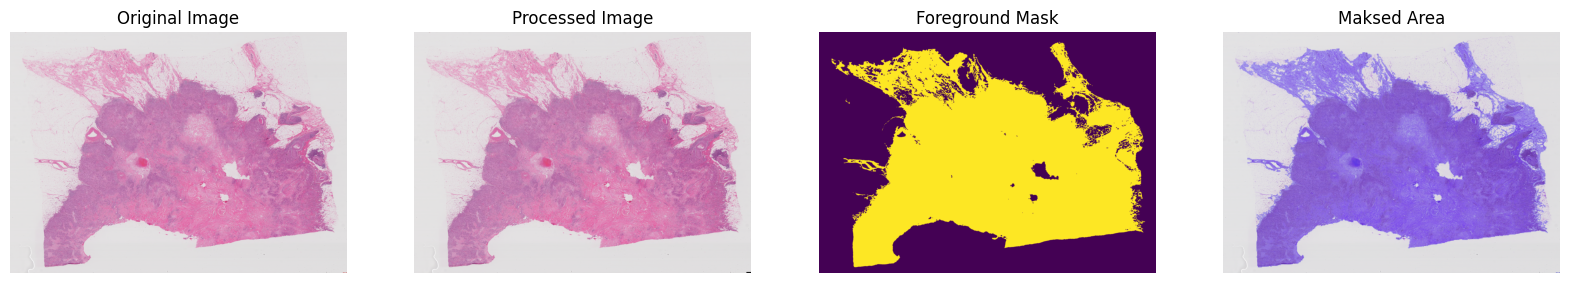

In [13]:
sampler = WSITileSampler(
        root_dir = dirs1,
        output_dir = os.path.join(os.getcwd(),'coords'),
        thumbnail_dir=os.path.join(os.getcwd(),'thumbnails_TCGA')
    )

masker = ForegroundMasker()

idx = 1

# results = sampler.process_images([files[idx]])


coDir = f'{os.getcwd()}/coords'
# files = [i for i in natsort.natsorted(os.listdir(coDir)) if i.endswith('.h5')]
os.makedirs(os.path.join(os.getcwd(),'sampling'),exist_ok=True)

# break
svsPath = os.path.join(dirs2,f"{files[idx]}.svs")
print(svsPath,files[idx])
wsi = openslide.OpenSlide(svsPath)
ratio = int(wsi.level_downsamples[-1])

with h5py.File(os.path.join(coDir,f"{files[idx]}.h5")) as f:
    coords = f['tile_coords'][:]
image = np.array(wsi.get_thumbnail(wsi.level_dimensions[-1]))
thumbnail = image.copy()

finals, final_mask = masker.get_foreground(image)
coords = (coords/ratio).astype(np.int32)

for x,y in coords:
    image = cv2.rectangle(image,(x,y),(x+int(256/ratio),y+8),(255,0,0),1)
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
cv2.imwrite(os.path.join(os.getcwd(),'sampling',f"{files[idx].replace('.h5','')}.png"),image)

images = [thumbnail,finals,final_mask,image]
imageTitle = ['Original Image', 'Processed Image', 'Foreground Mask', 'Maksed Area']

plt.figure(figsize=(20,40))

for id in range(4):
    plt.subplot(1,4,id+1)
    plt.title(imageTitle[id])
    plt.imshow(images[id])
    plt.axis('off')

## CLAM vis

In [ ]:
# sampler = WSITileSampler(
#         root_dir = dirs1,
#         output_dir = os.path.join(os.getcwd(),'coords'),
#         thumbnail_dir=os.path.join(os.getcwd(),'thumbnails_TCGA')
#     )

# masker = ForegroundMasker()

idx = 2

# results = sampler.process_images([files[idx]])


coDir = f'{os.getcwd()}/coordsCLAMKBSMC'

# files = [i for i in natsort.natsorted(os.listdir(coDir)) if i.endswith('.h5')]
# os.makedirs(os.path.join(os.getcwd(),'sampling'),exist_ok=True)

# break
svsPath = os.path.join(dirs1,f"{files[idx]}.svs")
# print(svsPath,files[idx])
wsi = openslide.OpenSlide(svsPath)
ratio = int(wsi.level_downsamples[-1])

with h5py.File(os.path.join(coDir,f"{files[idx]}_clam.h5")) as f:
    coords = f['coords'][:]
image = np.array(wsi.get_thumbnail(wsi.level_dimensions[-1]))
thumbnail = image.copy()

x,y,z = thumbnail.shape
print(x,y,z)
# finals, final_mask = masker.get_foreground(image)
coords = (coords/ratio).astype(np.int32)


finals = thumbnail.copy()
final_mask = np.zeros((x,y))
# print(final_mask.shape)
for x,y in coords:
    image = cv2.rectangle(image,(x,y),(x+int(256/ratio),y+8),(0,255,0),1)
    final_mask = cv2.rectangle(final_mask,(x,y),(x+int(256/ratio),y+8),(0,255,0),-1)
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
# cv2.imwrite(os.path.join(os.getcwd(),'sampling',f"{files[idx].replace('.h5','')}.png"),image)

images = [thumbnail,finals,final_mask,image]
imageTitle = ['Original Image', 'Processed Image', 'Foreground Mask', '']

plt.figure(figsize=(20,40))

for id in range(4):
    plt.subplot(1,4,id+1)
    plt.title(imageTitle[id])
    plt.imshow(images[id])
    plt.axis('off')

## Compare the visual results

In [3]:
clamDir = '/home/nas2_fast/Data/Pathology_project/TCGA-BRCA/embedded_features/coords'
histoDir = '/home/nas2_fast/Data/Pathology_project/TCGA-BRCA/embedded_features_deep_histo/coords'
dplbDir = '/home/nas2_fast/Data/Pathology_project/TCGA-BRCA/embedded_features_dplab/coords'
oursDir = '/home/nas2_fast/Codes/smlee/WSI_tile_sampling_final/coords'

clam = [i for i in natsort.natsorted(os.listdir(clamDir)) if i.endswith('.h5')]
histo = [i for i in natsort.natsorted(os.listdir(histoDir)) if i.endswith('.h5')]
dplab = [i for i in natsort.natsorted(os.listdir(dplbDir)) if i.endswith('.h5')]
ours = [i for i in natsort.natsorted(os.listdir(oursDir)) if i.endswith('.h5')]





In [56]:
names = 'TCGA-AN-A0FV-01Z-00-DX1.C0D02946-FCDA-472D-895D-7ACF5C96B264'
print(clam.index(f'{names}.h5'))
# print(histo.index(f'{names}.h5'))
print(dplab.index(f'{names}.h5'))
print(ours.index(f'{names}.h5'))

results = []



324
326
326


In [57]:
idx = 2

# results = sampler.process_images([files[idx]])

Dirs = [clamDir,dplbDir,oursDir]
# coDir = f'{os.getcwd()}/coordsCLAMKBSMC'
for dirmini in Dirs:
    coDir = dirmini

    # files = [i for i in natsort.natsorted(os.listdir(coDir)) if i.endswith('.h5')]
    # os.makedirs(os.path.join(os.getcwd(),'sampling'),exist_ok=True)

    # break
    svsPath = os.path.join(dirs2,f"{names}.svs")
    # print(svsPath,files[idx])
    wsi = openslide.OpenSlide(svsPath)
    ratio = int(wsi.level_downsamples[-1])

    if dirmini == clamDir:
        with h5py.File(os.path.join(coDir,f"{names}.h5")) as f:
            coords = f['coords'][:]
    else:
        with h5py.File(os.path.join(coDir,f"{names}.h5")) as f:
            coords = f['tile_coords'][:]
    image = np.array(wsi.get_thumbnail(wsi.level_dimensions[-1]))
    thumbnail = image.copy()

    x,y,z = thumbnail.shape
    print(x,y,z)
    # finals, final_mask = masker.get_foreground(image)
    coords = (coords/ratio).astype(np.int32)


    finals = thumbnail.copy()
    final_mask = np.zeros((x,y))
    # print(final_mask.shape)
    for x,y in coords:
        image = cv2.rectangle(image,(x,y),(x+int(256/ratio),y+8),(0,255,0),1)
        final_mask = cv2.rectangle(final_mask,(x,y),(x+int(256/ratio),y+8),(0,255,0),-1)
    # image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    # cv2.imwrite(os.path.join(os.getcwd(),'sampling',f"{files[idx].replace('.h5','')}.png"),image)
    results.append(image)


1640 2290 3
1640 2290 3
1640 2290 3


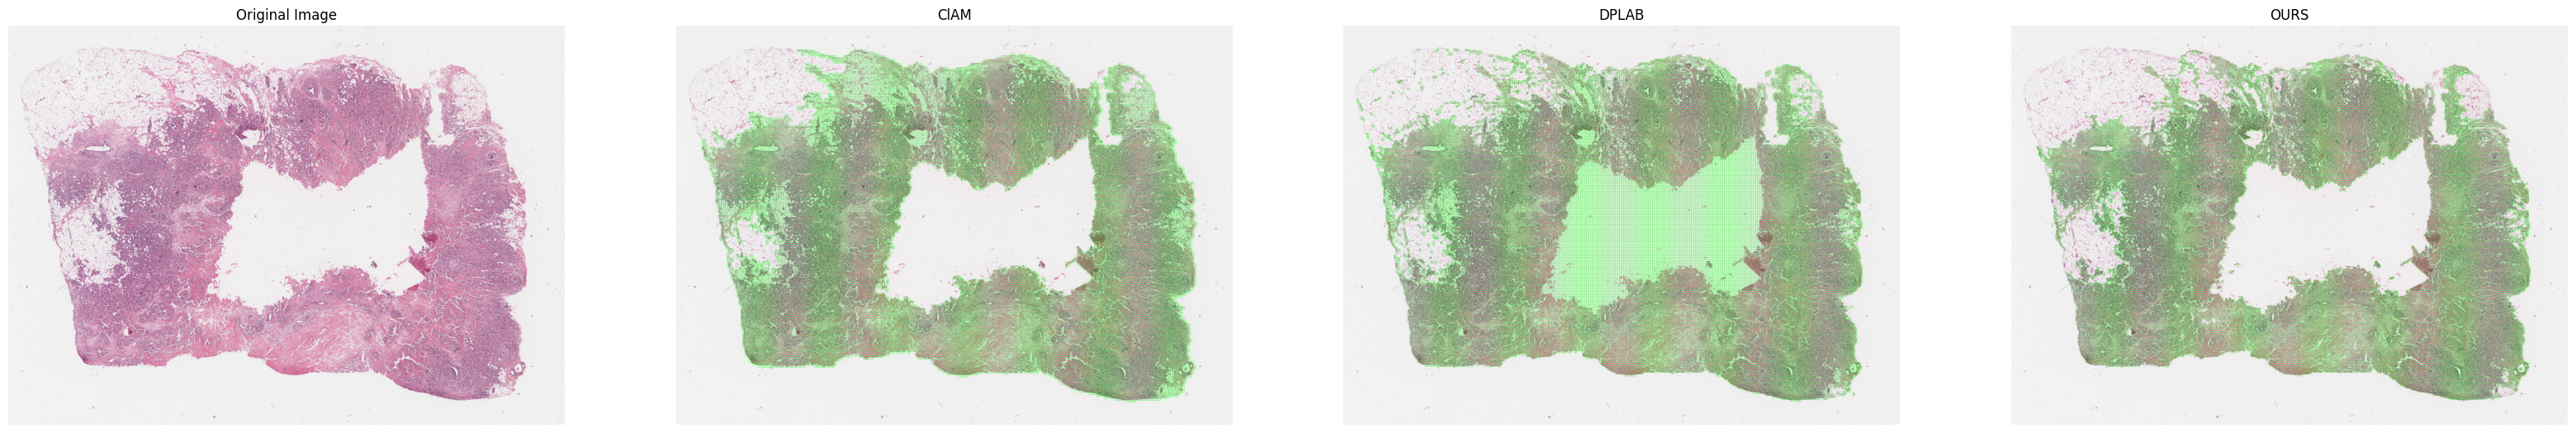

In [58]:
images = [thumbnail,finals,final_mask,image]
imageTitle = ['ClAM', 'DPLAB', 'OURS', '']

plt.figure(figsize=(40,80))
plt.subplot(1,4,1)
plt.title('Original Image')
plt.imshow(thumbnail)
plt.axis('off')

for id in range(3):
    plt.subplot(1,4,id+2)
    plt.title(imageTitle[id])
    plt.imshow(results[id])
    plt.axis('off')

In [1]:
from TileSampling import WSITileSampler
import os
root = '/home/nas2_fast/Data/Pathology_project/BRCAS/BRACS_WSI'
# ls = os.listdir(dirs)
folders = []
for idx in ['train','val','test']:
    dirs = os.path.join(root,idx)
    ls = os.listdir(dirs)
    for i in ls:
        for x in os.listdir(os.path.join(dirs,i)):
            folders.append(os.path.join(dirs,i,x))
print(folders)

['/home/nas2_fast/Data/Pathology_project/BRCAS/BRACS_WSI/train/Group_AT/Type_ADH', '/home/nas2_fast/Data/Pathology_project/BRCAS/BRACS_WSI/train/Group_AT/Type_FEA', '/home/nas2_fast/Data/Pathology_project/BRCAS/BRACS_WSI/train/Group_BT/Type_N', '/home/nas2_fast/Data/Pathology_project/BRCAS/BRACS_WSI/train/Group_BT/Type_PB', '/home/nas2_fast/Data/Pathology_project/BRCAS/BRACS_WSI/train/Group_BT/Type_UDH', '/home/nas2_fast/Data/Pathology_project/BRCAS/BRACS_WSI/train/Group_MT/Type_DCIS', '/home/nas2_fast/Data/Pathology_project/BRCAS/BRACS_WSI/train/Group_MT/Type_IC', '/home/nas2_fast/Data/Pathology_project/BRCAS/BRACS_WSI/val/Group_AT/Type_ADH', '/home/nas2_fast/Data/Pathology_project/BRCAS/BRACS_WSI/val/Group_AT/Type_FEA', '/home/nas2_fast/Data/Pathology_project/BRCAS/BRACS_WSI/val/Group_BT/Type_N', '/home/nas2_fast/Data/Pathology_project/BRCAS/BRACS_WSI/val/Group_BT/Type_PB', '/home/nas2_fast/Data/Pathology_project/BRCAS/BRACS_WSI/val/Group_BT/Type_UDH', '/home/nas2_fast/Data/Pathology

In [2]:
len(os.listdir('/home/nas2_fast/Codes/smlee/WSI_tile_sampling_final/coordsBRCAS'))

547

In [ ]:
from IPython.display import clear_output

for index in range(len(folders)):
    # index = 1
    tar = folders[index]
    print(tar)
    filelist = [idx.replace('.svs','') for idx in natsort.natsorted(os.listdir(tar)) if idx.endswith('.svs')]
    print(len(filelist))
    sampler = WSITileSampler(
        root_dir = tar,
        output_dir = os.path.join(os.getcwd(),'coordsBRCAS'),
        thumbnail_dir= os.path.join(os.getcwd(),'thumbnails_BRCAS'),
        end = 'svs'
    )
    results = sampler.process_images(filelist)
    clear_output()

/home/nas2_fast/Data/Pathology_project/BRCAS/BRACS_WSI/test/Group_MT/Type_IC
20
Settings file already exists: /home/nas2_fast/Codes/smlee/WSI_tile_sampling_final/settings.txt


2025-06-26 11:40:29,550 - INFO - Template loaded from: templates/tcga_brca_template.json
2025-06-26 11:40:29,551 - INFO - Template info: Created 2025-06-10T16:18:14.300234, Reference Hue=155.6
  0%|          | 0/20 [00:00<?, ?it/s]

Processing BRACS_286 ...
Original size: (139943, 72532)
Thumbnail size: (1133, 2186, 3)
Image I/O: 1.27712 sec
Foreground masking: 0.17191 sec


  5%|▌         | 1/20 [00:09<03:03,  9.65s/it]

Tiling complete. Metadata and tile coordinates saved as BRACS_286.h5
Tile sampling: 8.20107 sec
Processing BRACS_292 ...
Original size: (142799, 91764)
Thumbnail size: (1433, 2231, 3)
Image I/O: 1.78063 sec
Foreground masking: 0.21723 sec


...

Tiling complete. Metadata and tile coordinates saved as BRACS_1413.h5
Tile sampling: 9.26446 sec
Processing BRACS_1414 ...
Original size: (93624, 83479)
Thumbnail size: (2608, 2925, 3)
Image I/O: 3.28183 sec
Foreground masking: 0.47264 sec


 50%|█████     | 10/20 [01:52<02:00, 12.01s/it]

Tiling complete. Metadata and tile coordinates saved as BRACS_1414.h5
Tile sampling: 9.89994 sec
Processing BRACS_1578 ...
Original size: (79680, 74224)
Thumbnail size: (2319, 2490, 3)
Image I/O: 1.34616 sec
Foreground masking: 0.31118 sec


 55%|█████▌    | 11/20 [02:02<01:42, 11.37s/it]

Tiling complete. Metadata and tile coordinates saved as BRACS_1578.h5
Tile sampling: 8.25158 sec
Processing BRACS_1580 ...
Original size: (97608, 78066)
Thumbnail size: (2439, 3050, 3)
Image I/O: 1.19105 sec
Foreground masking: 0.71454 sec
